# Lab 1: First Contact with Sentinel-1 over Kraków

This notebook is designed to do four things:

1. initialize the Earth Engine environment,
2. load Sentinel-1 GRD data over Kraków,
3. compare how SAR brightness changes across time,
4. some introductory .

Students should become comfortable with:

- loading satellite data in Python,
- working with an `ee.ImageCollection`,
- computing simple summary products,
- plotting histograms,
- comparing maps through time.

By the end of this notebook, students should be able to:

- explain what a Sentinel-1 image collection is,
- filter the collection to a consistent subset of scenes,
- produce a median monthly image for a given year,
- compare brightness distributions between years,
- compute a simple change metric,
- describe what they think the observed differences might represent.

---

In [1]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import datetime

print("Imports loaded.")

Imports loaded.


## 1. Initialize Google Earth Engine

This notebook assumes the Earth Engine Python API is already installed and authenticated.

If you are running this for the first time on a new machine, you may need to run:

```python
ee.Authenticate()
```

and then initialize with the project ID.

In [2]:
ee.Initialize(project="fleet-petal-494108-c6")
print("Earth Engine initialized OK.")

Earth Engine initialized OK.


## 2. Define the area of interest and some reusable settings

We use a small rectangle around Kraków.

We will work with **Sentinel-1 GRD** scenes that satisfy a consistent set of filters:

- intersect the AOI,
- same month or date range,
- IW mode,
- both VV and VH available,
- ascending orbit,
- 10 m resolution.

Using consistent filtering is important because it reduces differences caused by acquisition geometry rather than real surface change.

**Question (4 pts): Throughout this lab, we will be comparing SAR GRD level data to compare the same AOI over different periods of time. Why is it important to keep the orbit direction consistent when comparing scenes over time?**

**ANSWER:**
It is important to keep the orbit direction consistent because SAR is a side-looking sensor.
Because the satellite views the Earth at an angle, the direction of the orbit (ascending/descending) determines from which side the radar beam illuminates the terrain. So, changing the viewing perspective changes how shadows, layover, and foreshortening appear in the image. For example, shadow casted by a building will fall in one direction in ascending pass and in the opposite direction during a descending.
By keeping the orbit consistent, we ensure that the geometry remains the same and we can conclude that any observed differences in the backscatter are due to real surface changes, rather than a different viewing angle.

In [3]:
# Area of interest: Kraków and surrounding urban/peri-urban area
aoi = ee.Geometry.Rectangle([19.85, 49.95, 20.20, 50.14])

# Analysis settings
ORBIT_PASS = "ASCENDING"
MODE = "IW"
RESOLUTION = 10

# Year range used later in the notebook
years = list(range(2015, 2025))

m = geemap.Map()
m.centerObject(aoi, 10)
m.addLayer(aoi, {"color": "red"}, "AOI")
display(m)

Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

## 3. Helper functions

These functions do most of the repetitive work:

- `get_s1_collection(...)`: build a filtered Sentinel-1 collection,
- `get_monthly_median(...)`: produce a median image for a given month and year,
- `show_scene_metadata(...)`: inspect dates and metadata,
- `fixed_histogram(...)`: compute a histogram for plotting,
- `region_stats(...)`: compute simple summary statistics over the AOI.

In [4]:
def get_s1_collection(start_date, end_date, region=aoi,
                      orbit_pass=ORBIT_PASS,
                      mode=MODE,
                      resolution=RESOLUTION):
    """
    Return a filtered Sentinel-1 GRD ImageCollection.
    """
    collection = (
        ee.ImageCollection("COPERNICUS/S1_GRD")
        .filterBounds(region)
        #YOUR CODE HERE (10 pts)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.eq("instrumentMode", mode))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VV"))
        .filter(ee.Filter.listContains("transmitterReceiverPolarisation", "VH"))
        .filter(ee.Filter.eq("orbitProperties_pass", orbit_pass))
        .filter(ee.Filter.eq("resolution_meters", resolution))
    )

    return collection


def get_monthly_median(year, month=8, region=aoi):
    """
    Return the median Sentinel-1 image for a given month and year.
    By default, this is August because it reduces seasonal variation
    and avoids snow-related complications.
    """
    start = f"{year}-{month:02d}-01"
    if month == 12:
        end = f"{year + 1}-01-01"
    else:
        end = f"{year}-{month + 1:02d}-01"

    #YOUR CODE HERE (10 pts). IN SECTION 4, YOU MANUALLY GOT THE COLLECTION AND SET THE MEDIAN.
    #SINCE WE INTEND TO DO THIS MULTIPLE TIMES, LETS PUT THIS IN A FUNCTION
    collection = get_s1_collection(start, end, region=region)
    image = collection.median().clip(region)

    return image.set({
        "year": year,
        "month": month,
        "scene_count": collection.size(),
        "system:time_start": ee.Date(start).millis(),
    })


def show_scene_metadata(collection):
    """
    Print selected metadata for scenes in a collection.
    Useful for discussing repeat intervals and duplicate dates.
    """
    #YOUR CODE HERE (10 pts). Fill in this function with additional metadata required to answer any questions you may have
    times = collection.aggregate_array("system:time_start").getInfo()
    passes = collection.aggregate_array("orbitProperties_pass").getInfo()
    platforms = collection.aggregate_array("platform_number").getInfo()
    rel_orbits = collection.aggregate_array("relativeOrbitNumber_start").getInfo()
    orbits = collection.aggregate_array("orbitNumber_start").getInfo()
    slices = collection.aggregate_array("sliceNumber").getInfo()
    total_slices = collection.aggregate_array("totalSlices").getInfo()
    indexes = collection.aggregate_array("system:index").getInfo()

    for t, p, sat, ro, o, sl, tsl, idx in zip(
        times, passes, platforms, rel_orbits, orbits, slices, total_slices, indexes
    ):
        dt = datetime.datetime.utcfromtimestamp(t / 1000)
        print(f"{dt.date()} | {p} | S1{sat} | relOrb {ro} | orb {o} | slice {sl}/{tsl} | {idx}")


def fixed_histogram(image, region, band, hist_min, hist_max, n_bins=100, scale=10):
    """
    Compute a fixed histogram for one band of an Earth Engine image.
    Returns bin centers, counts, and bin width.
    """
    hist = image.select(band).reduceRegion(
        reducer=ee.Reducer.fixedHistogram(hist_min, hist_max, n_bins),
        geometry=region,
        scale=scale,
        maxPixels=1e9,
        bestEffort=True
    ).get(band)

    hist = ee.List(hist).getInfo()
    bin_edges = [row[0] for row in hist]
    counts = [row[1] for row in hist]
    bin_width = (hist_max - hist_min) / n_bins
    bin_centers = [edge + bin_width / 2 for edge in bin_edges]

    return bin_centers, counts, bin_width


def normalize_counts(counts):
    total = sum(counts)
    if total == 0:
        return counts
    return [c / total for c in counts]


def region_stats(image, region, band):
    """
    Return mean, median, std dev, and max for a selected band.
    """
    stats = image.select(band).reduceRegion(
        reducer=(
            ee.Reducer.mean()
            .combine(ee.Reducer.median(), sharedInputs=True)
            .combine(ee.Reducer.stdDev(), sharedInputs=True)
            .combine(ee.Reducer.max(), sharedInputs=True)
        ),
        geometry=region,
        scale=10,
        maxPixels=1e9,
        bestEffort=True
    ).getInfo()

    return {
        "mean": stats.get(f"{band}_mean"),
        "median": stats.get(f"{band}_median"),
        "stdDev": stats.get(f"{band}_stdDev"),
        "max": stats.get(f"{band}_max"),
    }

print("Helper functions defined.")

Helper functions defined.


## 4. Inspect one month of data in detail

This section focuses on January 2024.  
The goal is no deep interpretation yet — it is simply to inspect the collection and compare the returned GRD file, comparing the scene with your a priori knowledge of the Krakow area.

We want to return a filtered Sentinel-11 GRD ImageCollection that is filtered by:
- region
- start_date and end_date
- instrumentMode = "IW"
- transmitterReceiverPolarisation contains both "VV" and "VH"
- orbitProperties_pass = "ASCENDING"
- resolution_meters = 10

Things you might notice:
- For a given AOI, multiple slices can exist,
- one overpass can be represented by multiple scene slices,
- image collections often contain more than one product per date over the AOI.



In [5]:
# Visualization presets
vv_vis = {"min": -20, "max": 0}
vh_vis = {"min": -28, "max": -5}
#YOU WILL NEED TO WRITE THE get_s1_collection FUNCTION TO GET THIS TO WORK. ONCE YOU HAVE
#THE FUNCTION WORKING, PLACE IT IN THE FUNCTIONS CODE BLOCK IN SECTION 3.
jan_2024 = get_s1_collection("2024-01-01", "2024-02-01", region=aoi)

#YOU WILL NEED TO ADAPT THE show_scene_metadata() FUNCTION TO ANSWER THE QUESTION BELOW
print("Image count:", jan_2024.size().getInfo())
show_scene_metadata(jan_2024)

jan_2024_img = jan_2024.median().clip(aoi)

m = geemap.Map()
m.centerObject(aoi, 10)

#If we were plotting just one img, you would simply use the line below. A split_map allows
#two scenes to be compared via a slider bar.
#m.addLayer(jan_2024_img.select("VV"), vv_vis, "VV January 2024")

m.split_map(
    left_layer=geemap.ee_tile_layer(jan_2024_img.select("VV"), vv_vis, "VV January 2024"),
    right_layer=geemap.ee_tile_layer(jan_2024_img.select("VH"), vh_vis, "VH January 2024")
)
display(m)

Image count: 10
2024-01-05 | ASCENDING | S1A | relOrb 102 | orb 51974 | slice 13/29 | S1A_IW_GRDH_1SDV_20240105T162704_20240105T162729_051974_0647C6_F348
2024-01-05 | ASCENDING | S1A | relOrb 102 | orb 51974 | slice 14/29 | S1A_IW_GRDH_1SDV_20240105T162729_20240105T162754_051974_0647C6_659B
2024-01-10 | ASCENDING | S1A | relOrb 175 | orb 52047 | slice 13/29 | S1A_IW_GRDH_1SDV_20240110T163516_20240110T163541_052047_064A3F_42D1
2024-01-10 | ASCENDING | S1A | relOrb 175 | orb 52047 | slice 14/29 | S1A_IW_GRDH_1SDV_20240110T163541_20240110T163606_052047_064A3F_6E2C
2024-01-17 | ASCENDING | S1A | relOrb 102 | orb 52149 | slice 13/29 | S1A_IW_GRDH_1SDV_20240117T162704_20240117T162729_052149_064DB5_C6D1
2024-01-17 | ASCENDING | S1A | relOrb 102 | orb 52149 | slice 14/29 | S1A_IW_GRDH_1SDV_20240117T162729_20240117T162754_052149_064DB5_7B40
2024-01-22 | ASCENDING | S1A | relOrb 175 | orb 52222 | slice 13/29 | S1A_IW_GRDH_1SDV_20240122T163515_20240122T163540_052222_065022_B219
2024-01-22 | ASCEN

Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

**QUESTION (4 pts): We know Sentinel-1 has an approximately 6-day repeat time. However, from the metadata presented above, there are 10 images that GEE grabbed, two for each acquisition day. Why is that? Do not guess, look into the metadata for those scenes to get your answer. You will need to modify the metadata function in the helper functions code block above. Please also adjust the print function to print the metadata field you thinks supports your answer**

Some common metadata fields are:`time_start`, `platform_number`, `orbitProperties_pass`, `relativeOrbitNumber_start`, `sliceNumber`, `totalSlices`, `instrumentMode`, `transmitterReceiverPolarisation`, `resolution_meters`, and `orbitNumber_start`. 

**ANSWER:**
Metadata analysis shows that for each acquisition day, there are two separate images because the Area of Interest is located on the boundary between two consecutive slices. Although the acquisition time and orbit number are the same, the sliceNumber field differs for these images (one is slice 13/29, the other is 14). This confirms that GEE is retrieving all data granules that intersect the Area of Interest.

## 5. Compare early and recent August composites

For the first change-oriented comparison, we use one August composite near the beginning and one near the end of the analysis period.

Why August?
- it helps keep the seasonal window consistent,
- it avoids winter snow issues,
- it gives a cleaner year-to-year comparison.

Why not August?
- Vegetative growth may impact radar returns (e.g., depending on the conditions earlier in the summer, foliage may be at a different growth level

> **If you are curious:**  
> Once you have finished the lab, you can change the month from August to January or April (or any of your choice) and describe how the maps, histograms, or time series plots differ. Maybe another month would be a better choice?


In [6]:
# Build one August median image for every year
images_by_year = {year: get_monthly_median(year, month=8, region=aoi) for year in years}

first_year = years[0]
last_year = years[-1]

img_first = images_by_year[first_year]
img_last = images_by_year[last_year]

m = geemap.Map()
m.centerObject(aoi, 11)
m.split_map(
    left_layer=geemap.ee_tile_layer(img_first.select("VV"), vv_vis, f"VV {first_year}"),
    right_layer=geemap.ee_tile_layer(img_last.select("VV"), vv_vis, f"VV {last_year}")
)
display(m)

Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

**QUESTION (8 pts): Compare the 2015 and 2025 median maps carefully.** 

- *Start with the old town. Do you notice much change? Why do you think that is?*
In the Old Town area, the change is relatively minimal compared to other districts. While there is a slight increase in bright pixels (new or renovated structures), the overall layout remains stable. This is because the Old Town is a historical preservation zone with strict building regulations, meaning most large-scale construction already existed in 2015 and significant new development is probably restricted.

- *Find an area that has significant change in bright pixels. What does this represent?*
Significant increases in bright pixels are visible in the outskirts, particularly in Bronowice (West) and the North-Eastern parts of Kraków. This represents the development of new residential housing estates. In SAR imagery, buildings act as corner reflectors ("double-bounce" effect), resulting in much bright pixels.

- *What about the darkest pixels?*
The darkest pixels represent waters like the Vistula River and various reservoirs. Water acts as a specular reflector, bouncing the radar signal away from the sensor, which results in low backscatter. While the Vistula remains stable, few changes are visible in the reservoirs:
at South-East (Brzegi, Kępa) areas appear to have expanded, likely due changes in water management. Although North (Zalew Zesławicki)reservoir appears to have shrunk or become more overgrown with vegetation.

- *Pixels or groups of pixels that are consistently bright across many years are excellent candidates for the persistent scatterer, which we will cover in a later lab. What features do you think might make excellent candidates for persistent scatterer analysis?*
Persistent Scatterers provide a very stable and strong radar return over long periods. Excellent candidates for PS analysis in Kraków include 
Large Bridges -> because they are stable, massive steel/concrete structures
Industrial Infrastructure -> large metal buildings or complexes;
Churches and Towers -> stable, vertical structures in the city center.


## 6. Histogram comparison of VV brightness

A histogram is a simple way to summarize the distribution of pixel brightness values over the AOI.

Here we compare the VV histograms for the first and last August composites.

This is useful because a map can be visually overwhelming, while a histogram can show whether:
- the distribution shifts,
- the bright tail changes,
- one year has more bright scatterers than another.

>Important note:
A histogram of the whole AOI is a blunt tool. If the signal is subtle, the result may be hard to interpret. That is okay — part of the lesson is learning that some analyses are more sensitive than others.

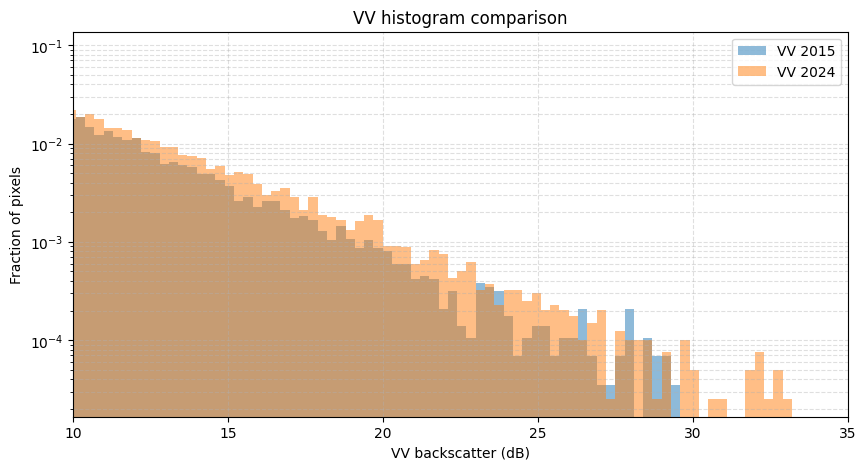

2015 VV stats: {'mean': -8.67223122960943, 'median': -8.875194515916217, 'stdDev': 3.06930373459068, 'max': 29.39563219751134}
2024 VV stats: {'mean': -9.286140736658618, 'median': -9.750873222813967, 'stdDev': 3.4265064649394494, 'max': 33.13410592782661}


In [7]:
# Histogram settings
vv_hist_min = 5
vv_hist_max = 35
vv_hist_bins = 100

x1, y1, bw1 = fixed_histogram(img_first, aoi, band="VV",
                              hist_min=vv_hist_min, hist_max=vv_hist_max,
                              n_bins=vv_hist_bins)
x2, y2, bw2 = fixed_histogram(img_last, aoi, band="VV",
                              hist_min=vv_hist_min, hist_max=vv_hist_max,
                              n_bins=vv_hist_bins)

y1n = normalize_counts(y1)
y2n = normalize_counts(y2)

plt.figure(figsize=(10, 5))
plt.bar(x1, y1n, width=bw1, alpha=0.5, label=f"VV {first_year}")
plt.bar(x2, y2n, width=bw2, alpha=0.5, label=f"VV {last_year}")
plt.xlabel("VV backscatter (dB)")
plt.ylabel("Fraction of pixels")
plt.title("VV histogram comparison")
plt.yscale("log")
plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.legend()
plt.xlim(10, 35)
plt.show()

stats_first = region_stats(img_first, aoi, "VV")
stats_last = region_stats(img_last, aoi, "VV")

print(f"{first_year} VV stats:", stats_first)
print(f"{last_year} VV stats:", stats_last)

**QUESTION (4 pts): What do you notice about the distribution on the bright side tail of the distribution of pixel brightness? Discuss both the number of bright pixels and their distribution, and what each represents. ADJUST THE X-AXIS IN THE CODE TO GRAB THE PART OF THE HISTOGRAM THAT SUPPORTS YOUR ANSWER BELOW**

**ANSWER:**
The histogram shows that the bright tail (values from approx. 10 dB to 35 dB) is consistently higher for 2024 (orange) than for 2015 (blue). What means there is a higher fraction of pixels with high backscatter values in the recent data. Additionally, the distribution extends further to the right -> the maximum value increased from 29.4 dB in 2015 to 33.1 dB in 2024.
The increase in the quantity of bright pixels represents the intensification of urban land cover, more of them are behaving as strong radar reflector. Also, the shift towards higher dB values represents the appearance of new, highly reflective structures. This supports my previous conclusions -> while the city center remains pretty stable, the development in areas like Bronowice or the North-East adds a significant number of high-intensity scatterers to the 2024 dataset.

## 7. Compute a simple SAR ratio image: VV - VH

A very simple and common calculation is the difference between the VV and VH bands:

\[
VV - VH
\]

This is not a full physical interpretation yet, but it is a useful derived quantity because it often separates surface types better than VV or VH alone. We will cover polarimetric SAR in later labs and lectures,
but the important thing to know here is that VV returns most strongly come from hard surface reflectors, things
like buildings, bridges, and roads, while VH returns most strongly come from distributed or volumetric scattering,
for example by bouncing many times in vegetative growth before returning to the satellite.

Here we compare the ratio-like image `VV - VH` for the first and last August composites.

To do this, select the VV band of the first image, subtract the VH band of the first image, then rename the result "VVVH" Then, do the same for the last image. Then, plot this as a split_map centered on the AOI.


In [8]:
ratio_first = img_first.select('VV').subtract(img_first.select('VH')).rename('VVVH')
ratio_last = img_last.select('VV').subtract(img_last.select('VH')).rename('VVVH')

vis_params = { 
    'min': 3,
    'max': 15,
    'palette': ['black', 'blue', 'purple', 'cyan', 'green', 'yellow', 'red']
}

Map = geemap.Map()
Map.centerObject(aoi, 12)

#layer prep
left_layer = geemap.ee_tile_layer(ratio_first, vis_params, f'VV-VH {first_year}')
right_layer = geemap.ee_tile_layer(ratio_last, vis_params, f'VV-VH {last_year}')

Map.split_map(left_layer, right_layer)
Map

Map(center=[50.04506888629718, 20.024999999999867], controls=(ZoomControl(options=['position', 'zoom_in_text',…

**QUESTION (4 pts): Where do you notice the biggest changes in the VV-VH ratio. Focus not only on the largest increases, but also the largest decreases. In doing so, are we making a qualitative or quantitative assesment?**

**ANSWER:**
The most notable trend is the spreading of low-difference values into areas that previously showed higher surface scattering. This indicates an increase in volume scattering, likely due to maturing or newly planted vegetation. In the Old Town (Main Market Square) and moving west toward Zwierzyniec (along Królowej Jadwigi) and Krowodrza/Bronowice, there is a clear spillover of low-ratio pixels, this aligns with the city's initiatives. A significant increase in volume scattering is visible also in Czyżyny, particularly around Park Lotników Polskich. More, the shopping centers on Jasnogórska (Bronowice), where decrease in the ratio is visible, while these areas are heavily built up, the surrounding landscape and  decorative tree planting have softened the radar return.

Mostly in the East Krakow, areas that used to be a mix of turquoise (mid-range differences) have consolidated into uniform, low-difference units. This suggests that the landscape has moved toward stabilized, vegetated areas or consistent urban greenery around residential centers.

Conversely, red clusters (high difference) represent new developments where surface scattering has become dominant. North of Prądnik Biały, small, intense clusters are appearing, likely representing new commercial service points or retail developments. The flat roofs and parking lots of these structures act as perfect surface reflectors widening the ratio.

## 8. Visualize change in VV - VH

Now we map the difference:

\[
(VV - VH)_{last} - (VV - VH)_{first}
\]

Positive values indicate an increase in this quantity through time, while negative values indicate a decrease.

At this stage, you should not over-interpret the result. The correct first step is simply to identify:
- where change appears strongest,
- whether it is spatially clustered,
- whether it seems plausible.



In [14]:
# Visualization presets
change_vis = {"min": -3, "max": 3, "palette": ["blue", "white", "red"]}

ratio_change = ratio_last.subtract(ratio_first).rename("dVVVH")

m2 = geemap.Map()
m2.centerObject(aoi, 11)
m2.addLayer(ratio_change, change_vis, "Change in VV-VH")
display(m2)

Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

**QUESTION (4 pts): Investigate this change map carefully.** 

- First, identify an area that had a large scale increase in this ratio. Why did VV increase relative to VH in this area?
- Second, I want you to find the area in the top right of the map that had a significant decrease in VV/VH. You can use the code block below to highlight where it is. Using optical data (google maps is fine here), tell me what that feature is. Why do you think it may have had strong VV in 2015, and strong VH in 2025, even though they were both taken in August?**

`aoi_blue = ee.Geometry.Rectangle([19.85, 49.95, 20.20, 50.14])`

`m2.addLayer(aoi, {"color": "red"}, "AOI")`

**ANSWER:**
1. These are likely areas of urban development, land clearing or deforestation (e.g., new construction sites or industrial zones). VV increased relative to VH, because when you remove trees or other vegetation, you remove the complex 3D structures that cause depolarization (that creates VH signal).By clearing the land or building structures with smooth walls and flat ground, we create an effect, that significantly boosts the VV signal because the energy is reflected directly back to the sensor without being depolarized into VH.

2. The areas visible in the upper right part of the map are smaller towns surrounded by farmland. In 2015, Poland experienced the "drought of the century." Crops in the fields around Wróżenice had withered or been harvested prematurely. The soil was bare and very dry. Dry, flat ground reflects the signal mainly in VV polarization. In August 2025, however, conditions were normal; assuming standard rainfall, the fully developed crops caused volumetric scattering, which amplified the VH signal.

## 9. Threshold-based change mask

This section turns a continuous change image into a very simple binary mask.

This is intentionally crude. The point is to show that:
- a threshold is a choice,
- different thresholds produce different maps,
- classification decisions require judgment.

The logic below flags pixels that:
- started relatively low,
- ended relatively high,
- increased by at least a chosen amount.

In [ ]:
low_thresh = 5      #VV/VH ratio is low (e.g. vegetation) at first 
high_thresh = 10     #VV/VH ratio is high (e.g. built-up area)
change_thresh = 3    #minimum 3db growth in VV-VH ratio

#WRITE THE LOGIC TO FLAG PIXELS THAT HAVE SATISFIED THE ABOVE THRESHOLDS. USEFUL LOGIC
#FUNCTIONS INCLUDE .And(), .Or(), .lt() for less than, .gt() for greater than
transition = (
    #YOUR CODE HERE (10 pts)
    #ratio at first lower than low_thresh
    ratio_first.lt(low_thresh)
    
    .And(
        #ratio higher than high_thresh later
        ratio_last.gt(high_thresh)
    )
    .And(
        #difference bigger than change_thresh
        ratio_change.gt(change_thresh)
    )
    #band name change 
    .rename("transition")
)

frac = transition.reduceRegion(
    reducer=ee.Reducer.mean(),
    geometry=aoi,
    scale=10,
    maxPixels=1e9
).get("transition").getInfo()

print("Fraction flagged:", frac)

m3 = geemap.Map()
m3.centerObject(aoi, 11)
m3.addLayer(img_last.select("VV"), vv_vis, f"VV {last_year}")
m3.addLayer(ratio_change, change_vis, "d(VV-VH)")
m3.addLayer(
    transition.updateMask(transition),
    {"min": 0, "max": 1, "palette": ["yellow"]},
    "Transition mask"
)
display(m3)

Fraction flagged: 0.004377401945485104


Map(center=[50.04506888629718, 20.024999999999867], controls=(WidgetControl(options=['position', 'transparent_…

**QUESTION (4 pts): Why did you choose the thresholds that you chose? Was it easy, or even possible, to arrive at a classification scheme that you think accurately captured urban development in the Krakow area?**

**ANSWER:**
The goal was to isolate the physical transition from vegetation to buildings. The chosen thresholds effectively isolate the transition from volume scattering in vegetation (low VV/VH ratio) to high-intensity double-bounce scattering from urban structures (high VV/VH ratio), ensuring that only physically significant changes are flagged. Additionally 3 dB threshold ensures the change is physically significant, acting like a noise filter.

Achieving a perfectly accurate map is difficult because factors such as building orientation relative to the radar beam, speckle noise, and soil moisture variations create geometric and intensity artifacts that simple binary logic cannot fully resolve (machine learning could be needed to capture everything in urban development for Krakow).

## 10. Histogram of the change image

This plot summarizes the distribution of the `VV - VH` change image.

It is useful for:
- seeing whether most pixels changed very little,
- checking whether the distribution is centered near zero,
- deciding whether the threshold values are reasonable.

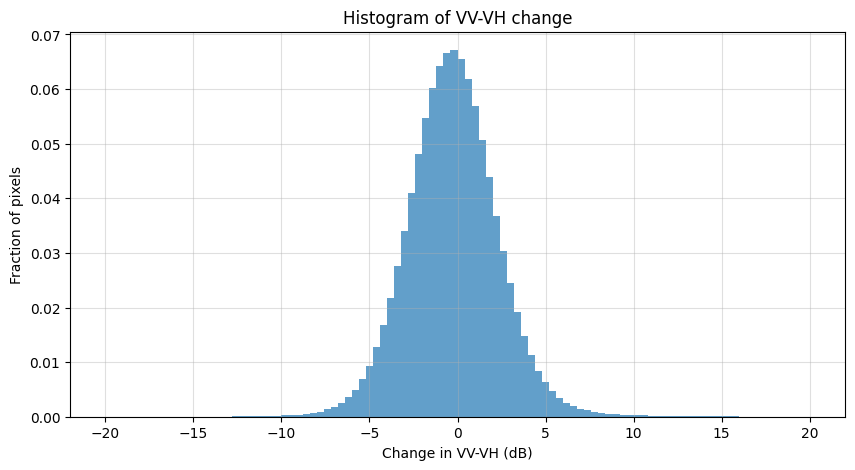

In [18]:
x_change, y_change, bw_change = fixed_histogram(
    ratio_change, aoi, "dVVVH", hist_min=-20, hist_max=20, n_bins=100
)

y_change_norm = normalize_counts(y_change)

plt.figure(figsize=(10, 5))
plt.bar(x_change, y_change_norm, width=bw_change, alpha=0.7)
plt.xlabel("Change in VV-VH (dB)")
plt.ylabel("Fraction of pixels")
plt.title("Histogram of VV-VH change")
plt.grid(True, alpha=0.4)
plt.show()

**QUESTION (4 pts):
First, notice that this histogram is not centered on 0, it is shifted slightly towards negative values. This means that VV is stronger in 2015 than in 2025! Does this go against all the analysis you just did? If this is confusing, go back to the very first split_image, comparing VV in 2015 and 2025. When we first did that, we were focused on the brightest pixels only. Now I want you to focus on the map as a whole, ignoring the brightest pixels. What can you say about the strength of VV returns in 2015 vs 2025. Thinking about what we have learned about scattering physics, what do you think might be the cause of this?**

**ANSWER:**
The histogram is shifted negative because, across the whole region, the landscape in 2025 had much more volume scattering (vegetation) than the "surface-scattering" dominated landscape of 2015. The peak of the histogram represents the agricultural fields and forests that make up the vast majority of the Kraków AOI. While individual buildings increased the ratio significantly, the landscape as a whole moved in the opposite direction.

As was noted earlier, August 2015 was exceptionally dry making VH extremely weak and creating high VV-VH ratio. In a more typical August, the vegetation is healthy and moisture-rich. This causes significant boost in the VH return ->> lower ratio.

## 11. Track a simple metric through time

Instead of comparing only two years, we can compute the same metric for every year.

Here we calculate the fraction of the AOI with:

\[
VV - VH > threshold
\]

for each August composite.

This is a very simple time-series summary. It is not a full change detection method, but it requires:
- looping over years,
- deriving one metric per image,
- plotting a time series.

,year,frac_flagged
0,2015,0.008090
1,2016,0.005889
2,2017,0.006533
3,2018,0.007412
4,2019,0.008260
5,2020,0.008935
6,2021,0.009731
7,2022,0.013092
8,2023,0.010260
9,2024,0.010684


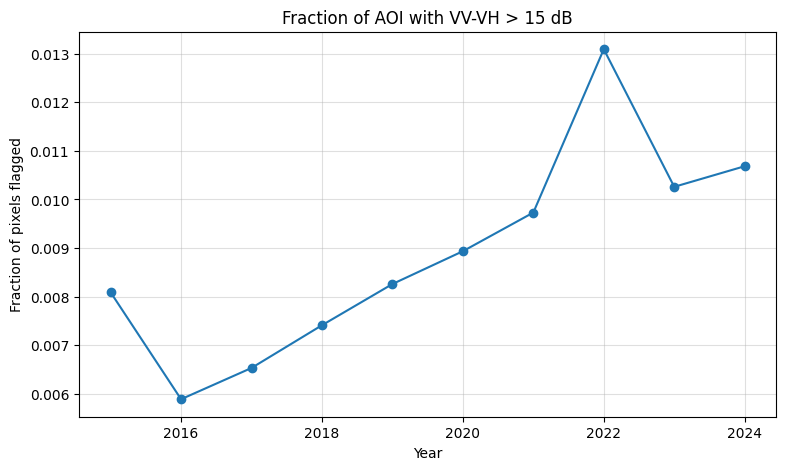

In [19]:
ratio_thresh = 15
rows = []

for year in years:
    yearly = images_by_year[year]
    ratio = yearly.select("VV").subtract(yearly.select("VH")).rename("VVVH")

    frac_flagged = ratio.gt(ratio_thresh).reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=10,
        maxPixels=1e9
    ).get("VVVH").getInfo()

    rows.append({
        "year": year,
        "frac_flagged": frac_flagged
    })

df = pd.DataFrame(rows)
display(df)

plt.figure(figsize=(9, 5))
plt.plot(df["year"], df["frac_flagged"], marker="o")
plt.xlabel("Year")
plt.ylabel("Fraction of pixels flagged")
plt.title(f"Fraction of AOI with VV-VH > {ratio_thresh} dB")
plt.grid(True, alpha=0.4)
plt.show()

**QUESTION (8 pts):**

- **Why did you choose the threshold that you did?**
- **This is our first attempt to actually quantify and track a specific metric of urban development over a longer time period. Do you think the metric you arrived at accurately quantifies the amount of urban development? Or do you think the metric shows overall trends in urban development, but that there may be too many assumptions to accurately quantify this?**
- **What do you think may be happening with the outliers?**

**ANSWER:**
1. The threshold of 15 dB was chosen to be highly conservative. By setting the bar at 15 dB, we are intentionally ignoring weak urban signals or noisy pixels to ensure that what is almost certainly a man-made structure. It acts as a filter to separate dense concrete/metal from natural surfaces like dry soil or rocky surfaces.
2. This metric is an excellent indicator of overall trends, but it is likely not an accurate quantification of the absolute amount of urban development. The general upward slope from 2016 to 2024 matches the known urban sprawl occurring in the outskirts of Kraków, as more concrete replaces fields.
Although, there are too many assumptions involved (for example, a building's orientation matters). Additionally, "mixed pixels" (pixels containing both a small house and a large garden) might fall just below the threshold, leading to an underestimation.
3. Massive jump in 2022 and the drop in 2016 are most likely driven by environmental conditions rather than a sudden construction or demolition of thousands of buildings.  Summer 2022 must had been exceptionally hot and dry across Europe. When vegetation is severely water-stressed, VH drops significantly, so the VV - VH ratio increases. This tricks the metric into thinking there is more urban area when it’s actually just very dry forest and soil. Conversely, 2016 might have had a particularly lush August with high soil moisture. This increases volume scattering from leaves and makes the ground more reflective in a way that can lower the VV - VH gap, masking some urban pixels.